<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Identify Key Stats based on Opening Market Trends
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

# Import Packages

In [36]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime, timedelta
import os
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import statsmodels.formula.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import yfinance as yf
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement
import Charts

# Grab Data for one Ticker

In [37]:
tickers = Indicators.save_sp500_tickers()
ticker = tickers[0]
ticker = 'GOOG'
#ticker = 'WDC'
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
df = Indicators.get_ticker(ticker,500)
df['day'] = df['date'].dt.date
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,day
0,2022-09-26 09:30:00-04:00,98.940,100.440,98.380,100.270,5558426,0.000,0.000,2022-09-26 09:30:00,GOOG,2022-09-26
1,2022-09-26 10:30:00-04:00,100.260,100.270,98.850,98.900,2878669,0.000,0.000,2022-09-26 10:30:00,GOOG,2022-09-26
2,2022-09-26 11:30:00-04:00,98.900,99.480,98.560,98.710,2241649,0.000,0.000,2022-09-26 11:30:00,GOOG,2022-09-26
3,2022-09-26 12:30:00-04:00,98.690,99.180,98.410,98.813,1772217,0.000,0.000,2022-09-26 12:30:00,GOOG,2022-09-26
4,2022-09-26 13:30:00-04:00,98.810,99.070,98.530,98.708,2020014,0.000,0.000,2022-09-26 13:30:00,GOOG,2022-09-26
...,...,...,...,...,...,...,...,...,...,...,...
3483,2024-09-20 11:30:00-04:00,163.370,164.119,163.350,164.100,1017953,0.000,0.000,2024-09-20 11:30:00,GOOG,2024-09-20
3484,2024-09-20 12:30:00-04:00,164.090,164.360,163.670,164.130,1051448,0.000,0.000,2024-09-20 12:30:00,GOOG,2024-09-20
3485,2024-09-20 13:30:00-04:00,164.145,164.310,163.535,163.650,1099947,0.000,0.000,2024-09-20 13:30:00,GOOG,2024-09-20
3486,2024-09-20 14:30:00-04:00,163.640,164.086,163.540,163.910,3062423,0.000,0.000,2024-09-20 14:30:00,GOOG,2024-09-20


# Add SMA, Min/Max, Events

In [5]:
SMAs = [5,30,60,90]
smoothing = 7
window = 7

df = Indicators.get_sma(df,SMAs)
events_df = {}
minmax = Indicators.get_max_min(df, smoothing, window)
for event in events:
    events_df[event] = getattr(Indicators,event)(minmax)
df

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,...,SMA30,SMA60,SMA90,day_start,day_open,day_end,prev_close,open_chng,next_high,next_high_chng
0,2022-09-13 09:30:00-04:00,108.889999,109.370003,106.849998,107.059998,6517074,0.0,0.0,2022-09-13 09:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.150002,-0.015979
1,2022-09-13 10:30:00-04:00,107.050003,107.150002,106.144997,106.241203,3797032,0.0,0.0,2022-09-13 10:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.900002,-0.018275
2,2022-09-13 11:30:00-04:00,106.239998,106.900002,106.184998,106.680000,2666482,0.0,0.0,2022-09-13 11:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.199997,-0.015520
3,2022-09-13 12:30:00-04:00,106.690002,107.199997,106.589996,107.129997,2648042,0.0,0.0,2022-09-13 12:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.360001,-0.014051
4,2022-09-13 13:30:00-04:00,107.129997,107.360001,106.529999,106.589996,2395254,0.0,0.0,2022-09-13 13:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.669998,-0.020388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3483,2024-09-09 11:30:00-04:00,149.419998,150.529999,149.280502,150.514999,2504933,0.0,0.0,2024-09-09 11:30:00,GOOG,...,156.730368,161.009180,163.174689,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,151.050003,-0.016473
3484,2024-09-09 12:30:00-04:00,150.520004,151.050003,150.470001,150.574997,2001186,0.0,0.0,2024-09-09 12:30:00,GOOG,...,156.391534,160.719097,162.958857,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,150.625000,-0.019241
3485,2024-09-09 13:30:00-04:00,150.578903,150.625000,149.570007,149.720001,2377939,0.0,0.0,2024-09-09 13:30:00,GOOG,...,156.034201,160.414430,162.739802,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,149.889999,-0.024027
3486,2024-09-09 14:30:00-04:00,149.720001,149.889999,148.589294,148.660004,3417927,0.0,0.0,2024-09-09 14:30:00,GOOG,...,155.636200,160.094931,162.514135,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,149.639999,-0.025654


### Add Previous Close price, Opening Day price, and the high from the second hour of the day

In [6]:
#df['day_open'] = df.mask.groupby([
df['day_start'] = df.groupby(['day'])['date'].transform('min')
df1 = df[df['date']==df['day_start']].copy()
df1.reset_index(inplace=True,drop=True)
df['day_open'] = df['day_start'].replace(dict(zip(df1['date'],df1['open'])))
df['day_end'] = df.groupby(['day'])['date'].transform('max')
df1 = df[df['date']==df['day_end']].copy()
df1.reset_index(inplace=True,drop=True)
df1['prev_close'] = df1['close'].shift(1)
df['prev_close'] = df['day_end'].replace(dict(zip(df1['date'],df1['prev_close'])))
df['open_chng'] = (df['day_open'] - df['prev_close'])/df['day_open']
df['open_chng'] = pd.to_numeric(df['open_chng'], errors='coerce')
df['next_high'] = df['high'].shift(-1)
df['next_high_chng'] = (df['next_high'] - df['day_open'])/df['day_open']
df['next_high_chng'] = pd.to_numeric(df['next_high_chng'], errors='coerce')
df.head(10)

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,...,SMA30,SMA60,SMA90,day_start,day_open,day_end,prev_close,open_chng,next_high,next_high_chng
0,2022-09-13 09:30:00-04:00,108.889999,109.370003,106.849998,107.059998,6517074,0.0,0.0,2022-09-13 09:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.150002,-0.015979
1,2022-09-13 10:30:00-04:00,107.050003,107.150002,106.144997,106.241203,3797032,0.0,0.0,2022-09-13 10:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.900002,-0.018275
2,2022-09-13 11:30:00-04:00,106.239998,106.900002,106.184998,106.680000,2666482,0.0,0.0,2022-09-13 11:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.199997,-0.015520
3,2022-09-13 12:30:00-04:00,106.690002,107.199997,106.589996,107.129997,2648042,0.0,0.0,2022-09-13 12:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.360001,-0.014051
4,2022-09-13 13:30:00-04:00,107.129997,107.360001,106.529999,106.589996,2395254,0.0,0.0,2022-09-13 13:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.669998,-0.020388
5,2022-09-13 14:30:00-04:00,106.589996,106.669998,105.940002,105.949997,3805127,0.0,0.0,2022-09-13 14:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,105.970001,-0.026816
6,2022-09-13 15:30:00-04:00,105.940002,105.970001,105.000000,105.320000,5153587,0.0,0.0,2022-09-13 15:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.029900,-0.026266
7,2022-09-14 09:30:00-04:00,105.440002,106.029900,104.589996,104.650002,5617245,0.0,0.0,2022-09-14 09:30:00,GOOG,...,NaN,NaN,NaN,2022-09-14 09:30:00,105.440002,2022-09-14 15:30:00,105.32,0.001138,105.599998,0.001517
8,2022-09-14 10:30:00-04:00,104.644997,105.599998,104.500000,105.190002,2895888,0.0,0.0,2022-09-14 10:30:00,GOOG,...,NaN,NaN,NaN,2022-09-14 09:30:00,105.440002,2022-09-14 15:30:00,105.32,0.001138,105.860001,0.003983
9,2022-09-14 11:30:00-04:00,105.199997,105.860001,105.040001,105.629997,2185271,0.0,0.0,2022-09-14 11:30:00,GOOG,...,NaN,NaN,NaN,2022-09-14 09:30:00,105.440002,2022-09-14 15:30:00,105.32,0.001138,106.099998,0.006259


### Keep only first hour of the day and Create Buckets

In [7]:
df2 = df[df['date']==df['day_start']].copy()
# First, we need to calculate our IQR.
field_name = 'open_chng'
q1 = df2[field_name].quantile(0.25)                 
q3 = df2[field_name].quantile(0.75)
iqr = q3 - q1

# Now let's calculate upper and lower bounds.
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

# Let us create our bins:
num_bins = 10
bin_width = (upper - lower) / num_bins
bins = [lower + i*bin_width for i in range(num_bins)]
bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

format(1/3, ".0%")
# Let us create our labels:
labels = [f'Bucket {format(bins[i], ".2%")} to {format(bins[i+1], ".2%")}' for i in range(1,num_bins+1)]
labels.append('Outside IQR')

# Finally, we add a new column to the df:
df2[field_name + '_bucket'] = pd.cut(df2[field_name], bins=bins, labels=labels)
df2.open_chng.describe()

count    499.000000
mean      -0.000478
std        0.013719
min       -0.084642
25%       -0.005054
50%       -0.000083
75%        0.004843
max        0.102519
Name: open_chng, dtype: float64

### Create SMA buckets

In [8]:
for s in SMAs:
    df2['Above {} day SMA'.format(s)] = np.where(df2['high'] > df2['SMA{}'.format(s)], 'Yes', 'No')

### Run Summary Stats

In [9]:
#df2[(df2.open_chng>=0.01)&(df2.open_chng<=0.02)].next_high_chng.describe()
groupcols = df2.groupby(field_name + '_bucket').next_high_chng.describe()

### Create Functions From Above

In [10]:
def add_prices(df):
    df['day_start'] = df.groupby(['day'])['date'].transform('min')
    df1 = df[df['date']==df['day_start']].copy()
    df1.reset_index(inplace=True,drop=True)
    df['day_open'] = df['day_start'].replace(dict(zip(df1['date'],df1['open'])))
    df['day_end'] = df.groupby(['day'])['date'].transform('max')
    df1 = df[df['date']==df['day_end']].copy()
    df1.reset_index(inplace=True,drop=True)
    df1['prev_close'] = df1['close'].shift(1)
    df['prev_close'] = df['day_end'].replace(dict(zip(df1['date'],df1['prev_close'])))
    df['open_chng'] = (df['day_open'] - df['prev_close'])/df['day_open']
    df['open_chng'] = pd.to_numeric(df['open_chng'], errors='coerce')
    df['next_high'] = df['high'].shift(-1)
    df['next_high_chng'] = (df['next_high'] - df['day_open'])/df['day_open']
    df['next_high_chng'] = pd.to_numeric(df['next_high_chng'], errors='coerce')
    
    return(df)

In [11]:
test = add_prices(df)
test

,datetime,open,high,low,close,volume,dividends,stock splits,date,ticker,...,SMA30,SMA60,SMA90,day_start,day_open,day_end,prev_close,open_chng,next_high,next_high_chng
0,2022-09-13 09:30:00-04:00,108.889999,109.370003,106.849998,107.059998,6517074,0.0,0.0,2022-09-13 09:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.150002,-0.015979
1,2022-09-13 10:30:00-04:00,107.050003,107.150002,106.144997,106.241203,3797032,0.0,0.0,2022-09-13 10:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.900002,-0.018275
2,2022-09-13 11:30:00-04:00,106.239998,106.900002,106.184998,106.680000,2666482,0.0,0.0,2022-09-13 11:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.199997,-0.015520
3,2022-09-13 12:30:00-04:00,106.690002,107.199997,106.589996,107.129997,2648042,0.0,0.0,2022-09-13 12:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,107.360001,-0.014051
4,2022-09-13 13:30:00-04:00,107.129997,107.360001,106.529999,106.589996,2395254,0.0,0.0,2022-09-13 13:30:00,GOOG,...,NaN,NaN,NaN,2022-09-13 09:30:00,108.889999,2022-09-13 15:30:00,NaT,NaN,106.669998,-0.020388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3483,2024-09-09 11:30:00-04:00,149.419998,150.529999,149.280502,150.514999,2504933,0.0,0.0,2024-09-09 11:30:00,GOOG,...,156.730368,161.009180,163.174689,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,151.050003,-0.016473
3484,2024-09-09 12:30:00-04:00,150.520004,151.050003,150.470001,150.574997,2001186,0.0,0.0,2024-09-09 12:30:00,GOOG,...,156.391534,160.719097,162.958857,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,150.625000,-0.019241
3485,2024-09-09 13:30:00-04:00,150.578903,150.625000,149.570007,149.720001,2377939,0.0,0.0,2024-09-09 13:30:00,GOOG,...,156.034201,160.414430,162.739802,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,149.889999,-0.024027
3486,2024-09-09 14:30:00-04:00,149.720001,149.889999,148.589294,148.660004,3417927,0.0,0.0,2024-09-09 14:30:00,GOOG,...,155.636200,160.094931,162.514135,2024-09-09 09:30:00,153.580002,2024-09-09 15:30:00,152.110001,0.009572,149.639999,-0.025654


In [12]:
def add_buckets(df2,field_name):
    # First, we need to calculate our IQR.
    q1 = df2[field_name].quantile(0.25)                 
    q3 = df2[field_name].quantile(0.75)
    iqr = q3 - q1

    # Now let's calculate upper and lower bounds.
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    # Let us create our bins:
    num_bins = 10
    bin_width = (upper - lower) / num_bins
    bins = [lower + i*bin_width for i in range(num_bins)]
    bins += [upper, float('inf')]  # Now we add our last bin, which will contain any value greater than the upper-bound of the IQR.

    # Let us create our labels:
    labels = [f'Bucket {format(bins[i], ".2%")} to {format(bins[i+1], ".2%")}' for i in range(1,num_bins+1)]
    labels.append('Outside IQR')

    # Finally, we add a new column to the df:
    df2[field_name + '_bucket'] = pd.cut(df2[field_name], bins=bins, labels=labels)
    
    return(df2)

In [13]:
field_name = 'open_chng'
test2 = test[test['date']==test['day_start']].copy()
test2 = add_buckets(test2,field_name)
test2.groupby(field_name + '_bucket').next_high_chng.describe()

,count,mean,std,min,25%,50%,75%,max
open_chng_bucket,,,,,,,,
Bucket -1.59% to -1.20%,17.0,0.003778,0.009370,-0.011653,-0.002946,0.003454,0.009661,0.024492
Bucket -1.20% to -0.80%,16.0,-0.000672,0.009410,-0.015408,-0.008461,0.001568,0.005742,0.013539
Bucket -0.80% to -0.41%,28.0,0.002634,0.009648,-0.021314,-0.003782,0.002868,0.007644,0.026407
Bucket -0.41% to -0.01%,72.0,0.005302,0.008435,-0.010194,-0.000722,0.004916,0.009983,0.027391
Bucket -0.01% to 0.39%,98.0,0.005572,0.009615,-0.019041,-0.000237,0.005513,0.012016,0.033021
Bucket 0.39% to 0.78%,106.0,0.005719,0.009956,-0.020357,-0.000535,0.005052,0.010950,0.041049
Bucket 0.78% to 1.18%,60.0,0.001802,0.010221,-0.043465,-0.003275,0.002126,0.008402,0.021623
Bucket 1.18% to 1.57%,48.0,0.006064,0.010900,-0.019667,0.001242,0.006600,0.012070,0.029459
Bucket 1.57% to 1.97%,12.0,0.003897,0.013798,-0.023294,-0.004661,0.002153,0.013418,0.028221


### Run Functions through Loop to get at Tickers listed below

In [14]:
tickers2 = ['AMZN','GOOG','META','NFLX','T','EBAY','NRG','TSLA']
field_name = 'open_chng'
final = pd.DataFrame()
for ticker in tickers2:
    df = Indicators.get_ticker(ticker,500)
    df['day'] = df['date'].dt.date
    df = add_prices(df)
    df2 = df[df['date']==df['day_start']].copy()
    final = pd.concat([final,df2],axis=0)

final = add_buckets(final,field_name)
final.groupby(field_name + '_bucket').next_high_chng.describe()

,count,mean,std,min,25%,50%,75%,max
open_chng_bucket,,,,,,,,
Bucket -1.67% to -1.25%,83.0,0.005894,0.015910,-0.033780,-0.004024,0.004074,0.012570,0.049824
Bucket -1.25% to -0.82%,141.0,0.007833,0.016738,-0.038473,-0.003646,0.005236,0.017097,0.071436
Bucket -0.82% to -0.40%,280.0,0.005795,0.013806,-0.038718,-0.002666,0.005374,0.015171,0.046098
Bucket -0.40% to 0.02%,517.0,0.006056,0.011645,-0.036091,-0.001113,0.005342,0.012576,0.060400
Bucket 0.02% to 0.44%,851.0,0.004874,0.011574,-0.036187,-0.002376,0.004418,0.011666,0.056696
Bucket 0.44% to 0.86%,834.0,0.005317,0.011645,-0.055975,-0.001506,0.004406,0.011679,0.074240
Bucket 0.86% to 1.28%,494.0,0.005129,0.011416,-0.043465,-0.001966,0.004019,0.011946,0.052541
Bucket 1.28% to 1.70%,285.0,0.004292,0.013501,-0.049066,-0.004479,0.003629,0.011834,0.048363
Bucket 1.70% to 2.12%,131.0,0.006041,0.014835,-0.046319,-0.002601,0.006498,0.015469,0.052341


### Now we will run Measurement Main to find Stocks that are X% below SMAs

In [15]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
bound = 0.03
SMAs = [30,60,90]

In [39]:
df3, final4 = Measurement.main(events, SMAs, smoothing, window, M, K, bound)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


In [41]:
pvar = .10
smavar = 30
rolvar = 50
smacol = 'SMA{}'.format(smavar)
smacol1 = 'SMA{}_outlier'.format(smavar)
smacol2 = 'SMA{}_future'.format(smavar)
df3 = df3.sort_values(['ticker','date'], ascending=(1,1))
#df3[df3.high < df3.SMA30*(1-pvar)]
df3[smacol1] = np.where(df3.high < df3[smacol]*(1-pvar), 1, 0)
#df3[smacol2] = df3.groupby(['ticker'])['high'].apply(lambda x: (x.shift(-90)-x)/x)
df3[smacol2] = df3.groupby(['ticker'])['high'].apply(lambda x: x.rolling(window = rolvar, center=False).max())
df3[smacol2] = df3.groupby(['ticker'])[smacol2].apply(lambda x: x.shift(-rolvar))
df3[smacol2] = (df3[smacol2] - df3['high'])/df3['high']
final = df3[df3[smacol1]==1][['date','open','high','low','close','ticker',smacol,smacol2]].sort_values(['date'],ascending=0)
final.reset_index(inplace=True, drop=True)
final['date'] = pd.to_datetime(final['date'])
final['timeDiff'] = pd.to_numeric(final.groupby('ticker')['date'].apply(lambda x: x-x.shift(1)))/1000**3/60
final[final.timeDiff < - 1200].head(20)

,date,open,high,low,close,ticker,SMA30,SMA30_future,timeDiff
0,2024-09-20 15:30:00,256.300,256.630,254.620,254.640,FDX,289.035,NaN,-153722867.281
7,2024-09-13 10:30:00,67.080,67.370,65.825,66.420,MRNA,75.053,NaN,-153722867.281
8,2024-09-12 11:30:00,66.480,67.175,65.680,67.080,MRNA,75.772,NaN,-1380.000
11,2024-09-05 14:30:00,66.870,68.130,66.720,67.750,DLTR,75.795,0.058,-153722867.281
21,2024-09-04 12:30:00,81.890,82.010,81.010,81.315,DG,91.413,0.052,-153722867.281
35,2024-08-30 15:30:00,83.940,84.070,82.680,83.000,DG,106.467,0.024,-5400.000
40,2024-08-30 11:30:00,427.000,436.220,426.130,428.487,SMCI,487.822,0.064,-153722867.281
65,2024-08-08 13:30:00,541.295,546.520,539.720,546.210,MCK,607.530,0.021,-153722867.281
66,2024-08-08 12:30:00,44.765,45.100,44.500,44.785,MNST,50.205,0.054,-153722867.281
69,2024-08-08 10:30:00,6.905,7.000,6.820,6.985,WBD,7.794,0.076,-153722867.281


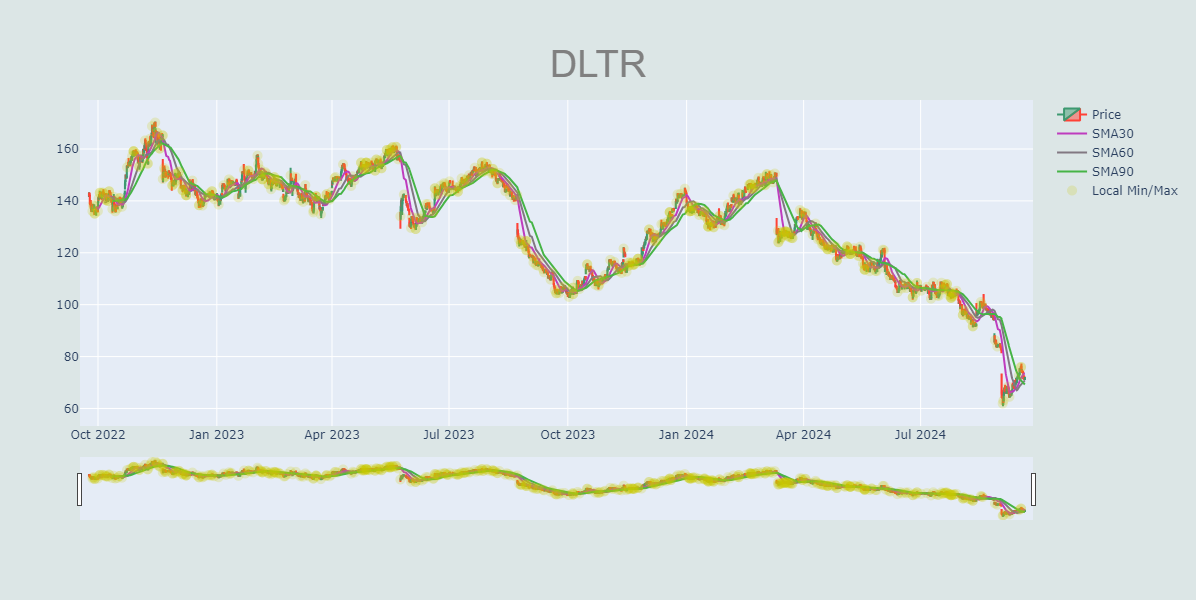

In [44]:
ticker = 'DLTR'
df4 = df3[df3.ticker==ticker].copy()
minmax = Indicators.get_max_min(df4, smoothing, window)
fig = go.Figure(data=[go.Candlestick(x=df4['date'],
                open=df4['open'],
                high=df4['high'],
                low=df4['low'],
                close=df4['close'],
                name='Price')])
for n in SMAs:
        rgb = 'rgb({},{},{})'.format(250-n*2,n*2,250-n*2)
        fig.add_trace(go.Scatter(x=df4['date'],
                y=df4['SMA{}'.format(n)],
                mode='lines',
                name='SMA{}'.format(n),
                line=dict(color=rgb)))
fig.add_trace(go.Scatter(x=minmax['date'],
                y=minmax['close'],
                mode='markers',
                name='Local Min/Max',
                marker=dict(color='rgb(200,200,0)',
                            size=10,
                            opacity=0.2)
                        ))
 
fig.update_xaxes(
        rangeslider_visible=True,
        rangebreaks=[
            # NOTE: Below values are bound (not single values), ie. hide x to y
            dict(bounds=["sat", "mon"]),  # hide weekends, eg. hide sat to before mon
            dict(bounds=[16, 9.5], pattern="hour"),  # hide hours outside of 9.30am-4pm
            #dict(values=["2024-12-25", "2024-01-01","2024-01-15","2024-02-19"])  # hide holidays (Christmas and New Year's, etc)
            ]
    )
fig.update_layout(title={'text':ticker, 'xanchor':'center', 'yanchor':'top','x':0.5},
                height=600,
                title_font={"family":"arial","color":"gray","size":38},
                paper_bgcolor='rgb(220,230,230)'
                 )
fig.show()

In [102]:
downpercent = len(df3[(df3[smacol1]==1)&(df3[smacol2] < 0)])/len(df3[df3[smacol1]==1])
avginc = df3[df3[smacol1]==1][smacol2].mean()
medinc = df3[df3[smacol1]==1][smacol2].median()
maxinc = df3[df3[smacol1]==1][smacol2].max()
print('Percent of Unsuccsessful observations is: {}'.format(format(downpercent,".2%")))
print('Average Increase/Decrease is: {}'.format(format(avginc,".2%")))
print('Median Increase/Decrease is: {}'.format(format(medinc,".2%")))
print('Maximum Increase/Decrease is: {}'.format(format(maxinc,".2%")))
df3[df3[smacol1]==1].groupby(['ticker'])[smacol2].describe().reset_index()

Percent of Unsuccsessful observations is: 11.01%
Average Increase/Decrease is: 6.52%
Median Increase/Decrease is: 4.77%
Maximum Increase/Decrease is: 48.64%


,ticker,count,mean,std,min,25%,50%,75%,max
0,AAL,13.0,0.030134,0.016637,-0.018085,0.025322,0.036892,0.038696,0.042321
1,ABNB,6.0,0.135930,0.027220,0.099714,0.113734,0.149279,0.154535,0.159134
2,ADBE,24.0,0.015160,0.029708,-0.032097,-0.002969,0.005511,0.043493,0.066424
3,ADM,16.0,0.049919,0.027866,-0.025807,0.045144,0.053926,0.067368,0.083572
4,ALB,12.0,0.088176,0.033661,0.004443,0.079605,0.085929,0.100920,0.138377
...,...,...,...,...,...,...,...,...,...
149,WYNN,10.0,0.017164,0.013437,0.000578,0.008214,0.015971,0.025275,0.041782
150,XEL,4.0,0.070505,0.003641,0.065361,0.069858,0.071357,0.072004,0.073947
151,XYL,1.0,0.039920,NaN,0.039920,0.039920,0.039920,0.039920,0.039920
152,ZBRA,25.0,0.063693,0.046633,-0.006171,0.023608,0.073601,0.093581,0.158349


In [103]:
df3[df3[smacol1]==1][smacol2].describe()

count    1888.000000
mean        0.065195
std         0.073294
min        -0.128767
25%         0.015485
50%         0.047740
75%         0.093585
max         0.486355
Name: SMA30_future, dtype: float64